In [6]:
import pandas as pd
from scipy import stats

import sys
sys.path.insert(0, '..')

from dataloader import load_df, load_perframe_pervalue, PARAM_LABELS, PARAMS,RESOLUTIONS, RESOLUTION_LABELS

df = load_df("../dataset.json", center=False)
print(df.shape)
print(df.groupby(['parameter', 'resolution']).size())

(2240, 6)
parameter     resolution
alpha_weight  50            240
              71            240
              87            240
              100           240
filter_size   50            140
              71            140
              87            140
              100           140
hist_percent  50             80
              71             80
              87             80
              100            80
num_samples   50            100
              71            100
              87            100
              100           100
dtype: int64


In [7]:
from scipy import stats
import numpy as np

ks_results = []

for (param, res), group in df.groupby(['parameter', 'resolution']):
    scores = group['score'].values
    mean, std = scores.mean(), scores.std()
    
    stat, pval = stats.kstest(scores, 'norm', args=(mean, std))
    
    ks_results.append({
        'parameter':  param,
        'resolution': res,
        'n':          len(scores),
        'mean':       round(mean, 3),
        'std':        round(std, 3),
        'ks_stat':    round(stat, 4),
        'p_value':    round(pval, 4),
        'normal':     pval >= 0.05,
    })

ks_df = pd.DataFrame(ks_results).sort_values(['parameter', 'resolution'])
print(ks_df.to_string(index=False))

   parameter  resolution   n   mean   std  ks_stat  p_value  normal
alpha_weight          50 240 86.156 9.078   0.1232   0.0012   False
alpha_weight          71 240 91.290 6.117   0.1396   0.0002   False
alpha_weight          87 240 93.155 5.064   0.1539   0.0000   False
alpha_weight         100 240 94.237 4.537   0.1700   0.0000   False
 filter_size          50 140 87.356 7.808   0.1461   0.0045   False
 filter_size          71 140 91.133 6.305   0.1563   0.0019   False
 filter_size          87 140 92.397 5.751   0.1684   0.0006   False
 filter_size         100 140 93.292 5.368   0.1904   0.0001   False
hist_percent          50  80 87.430 7.526   0.1293   0.1260    True
hist_percent          71  80 91.818 5.776   0.1496   0.0500   False
hist_percent          87  80 93.162 5.231   0.1760   0.0123   False
hist_percent         100  80 94.048 4.870   0.1975   0.0033   False
 num_samples          50 100 87.335 7.821   0.1446   0.0274   False
 num_samples          71 100 91.148 6.307   0.15

In [8]:
# Demean by scene within each (parameter, resolution) group
df['score_demeaned'] = (
    df.groupby(['scene', 'parameter', 'resolution'])['score']
    .transform(lambda x: x - x.mean())
)

ks_results_demeaned = []

for (param, res), group in df.groupby(['parameter', 'resolution']):
    scores = group['score_demeaned'].values
    mean, std = scores.mean(), scores.std()

    stat, pval = stats.kstest(scores, 'norm', args=(mean, std))

    ks_results_demeaned.append({
        'parameter':  param,
        'resolution': res,
        'n':          len(scores),
        'std':        round(std, 3),
        'ks_stat':    round(stat, 4),
        'p_value':    round(pval, 4),
        'normal':     pval >= 0.05,
    })

ks_df2 = pd.DataFrame(ks_results_demeaned).sort_values(['parameter', 'resolution'])
print(ks_df2.to_string(index=False))

   parameter  resolution   n   std  ks_stat  p_value  normal
alpha_weight          50 240 3.027   0.1754   0.0000   False
alpha_weight          71 240 1.465   0.1273   0.0008   False
alpha_weight          87 240 1.206   0.1267   0.0008   False
alpha_weight         100 240 1.338   0.1525   0.0000   False
 filter_size          50 140 0.093   0.2261   0.0000   False
 filter_size          71 140 0.108   0.2543   0.0000   False
 filter_size          87 140 0.130   0.2264   0.0000   False
 filter_size         100 140 0.129   0.2720   0.0000   False
hist_percent          50  80 0.695   0.1523   0.0437   False
hist_percent          71  80 0.666   0.1339   0.1034    True
hist_percent          87  80 0.712   0.1293   0.1258    True
hist_percent         100  80 0.708   0.1106   0.2618    True
 num_samples          50 100 0.104   0.1800   0.0026   False
 num_samples          71 100 0.122   0.2081   0.0003   False
 num_samples          87 100 0.133   0.2400   0.0000   False
 num_samples         100

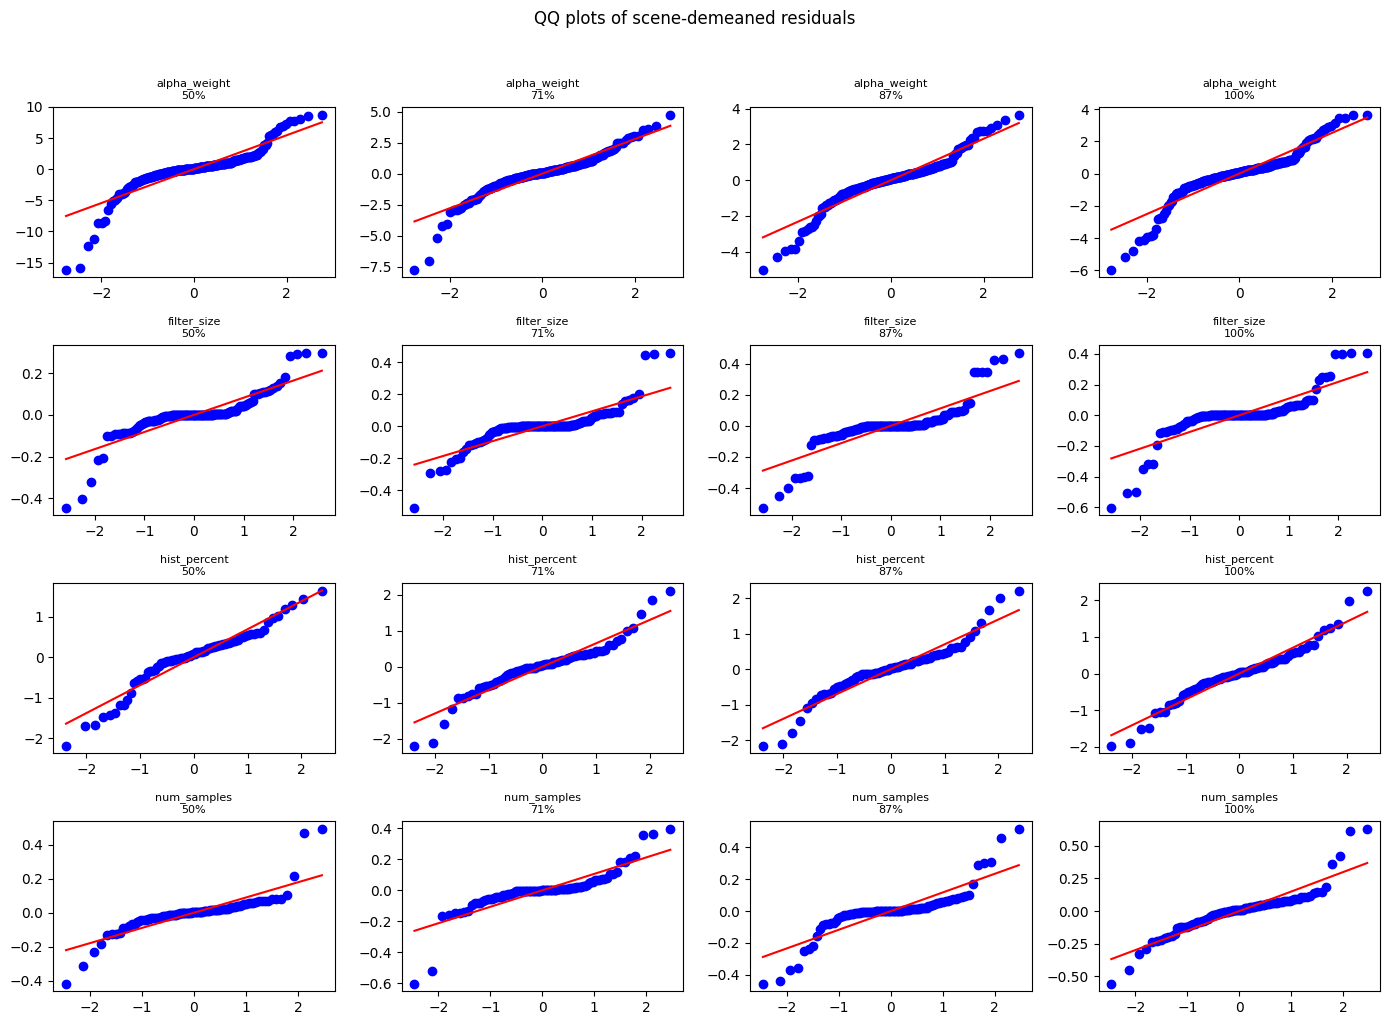

In [9]:
import matplotlib.pyplot as plt
from scipy import stats

params = df['parameter'].unique()
resolutions = sorted(df['resolution'].unique())

fig, axes = plt.subplots(len(params), len(resolutions), 
                         figsize=(14, 10), tight_layout=True)

for i, param in enumerate(params):
    for j, res in enumerate(resolutions):
        ax = axes[i, j]
        mask = (df['parameter'] == param) & (df['resolution'] == res)
        residuals = df.loc[mask, 'score_demeaned'].values
        
        stats.probplot(residuals, dist="norm", plot=ax)
        ax.set_title(f"{param}\n{res}%", fontsize=8)
        ax.set_xlabel("")
        ax.set_ylabel("")

plt.suptitle("QQ plots of scene-demeaned residuals", y=1.02)
plt.show()

In [10]:
from scipy import stats
import pandas as pd

results = []

for (param, res), group in df.groupby(['parameter', 'resolution']):
    groups_by_value = [g['score_demeaned'].values 
                       for _, g in group.groupby('value')]
    
    # ANOVA
    anova_stat, anova_p = stats.f_oneway(*groups_by_value)
    
    # Kruskal-Wallis
    kw_stat, kw_p = stats.kruskal(*groups_by_value)
    
    results.append({
        'parameter':      param,
        'resolution':     res,
        'anova_stat':     round(anova_stat, 3),
        'anova_p':        round(anova_p, 4),
        'anova_sig':      anova_p < 0.05,
        'kw_stat':        round(kw_stat, 3),
        'kw_p':           round(kw_p, 4),
        'kw_sig':         kw_p < 0.05,
        'agree':          (anova_p < 0.05) == (kw_p < 0.05),
    })

results_df = pd.DataFrame(results).sort_values(['parameter', 'resolution'])
print(results_df.to_string(index=False))

   parameter  resolution  anova_stat  anova_p  anova_sig  kw_stat   kw_p  kw_sig  agree
alpha_weight          50      13.265   0.0000       True  152.861 0.0000    True   True
alpha_weight          71      11.658   0.0000       True  114.580 0.0000    True   True
alpha_weight          87      14.993   0.0000       True  131.402 0.0000    True   True
alpha_weight         100      15.036   0.0000       True  150.386 0.0000    True   True
 filter_size          50       0.303   0.9344      False    4.572 0.5998   False   True
 filter_size          71       0.103   0.9959      False    2.252 0.8951   False   True
 filter_size          87       0.127   0.9928      False    4.347 0.6298   False   True
 filter_size         100       4.290   0.0006       True   24.651 0.0004    True   True
hist_percent          50       2.924   0.0392       True   13.992 0.0029    True   True
hist_percent          71      22.916   0.0000       True   50.141 0.0000    True   True
hist_percent          87      31

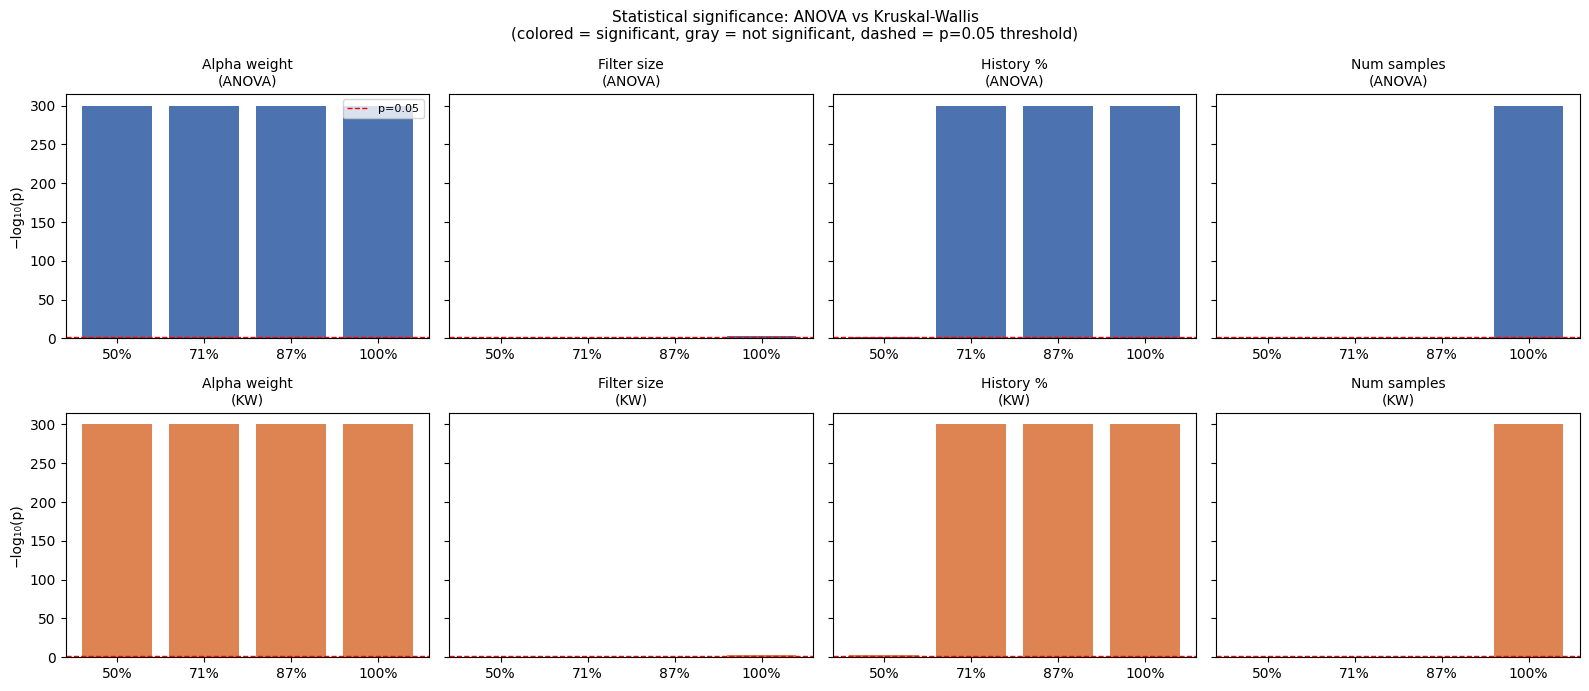

In [11]:
import matplotlib.pyplot as plt
import numpy as np

params = ['alpha_weight', 'filter_size', 'hist_percent', 'num_samples']
resolutions = [50, 71, 87, 100]
param_labels = {'alpha_weight': 'Alpha weight', 'filter_size': 'Filter size', 
                'hist_percent': 'History %', 'num_samples': 'Num samples'}

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey='row')

for j, param in enumerate(params):
    param_data = results_df[results_df['parameter'] == param]
    
    anova_ps = [-np.log10(max(p, 1e-300)) for p in param_data['anova_p']]
    kw_ps    = [-np.log10(max(p, 1e-300)) for p in param_data['kw_p']]
    
    x = np.arange(len(resolutions))
    width = 0.35
    sig_threshold = -np.log10(0.05)  # dashed line at p=0.05

    for row, (ps, label, color) in enumerate([(anova_ps, 'ANOVA', '#4C72B0'), 
                                               (kw_ps,   'KW',    '#DD8452')]):
        ax = axes[row, j]
        bars = ax.bar(x, ps, color=[
            color if p >= sig_threshold else 'lightgray' for p in ps
        ])
        ax.axhline(sig_threshold, color='red', linestyle='--', linewidth=1, label='p=0.05')
        ax.set_xticks(x)
        ax.set_xticklabels([f"{r}%" for r in resolutions])
        ax.set_title(f"{param_labels[param]}\n({label})", fontsize=10)
        if j == 0:
            ax.set_ylabel("−log₁₀(p)", fontsize=10)
        if row == 0 and j == 0:
            ax.legend(fontsize=8)

plt.suptitle("Statistical significance: ANOVA vs Kruskal-Wallis\n(colored = significant, gray = not significant, dashed = p=0.05 threshold)", 
             fontsize=11)
plt.tight_layout()
plt.show()

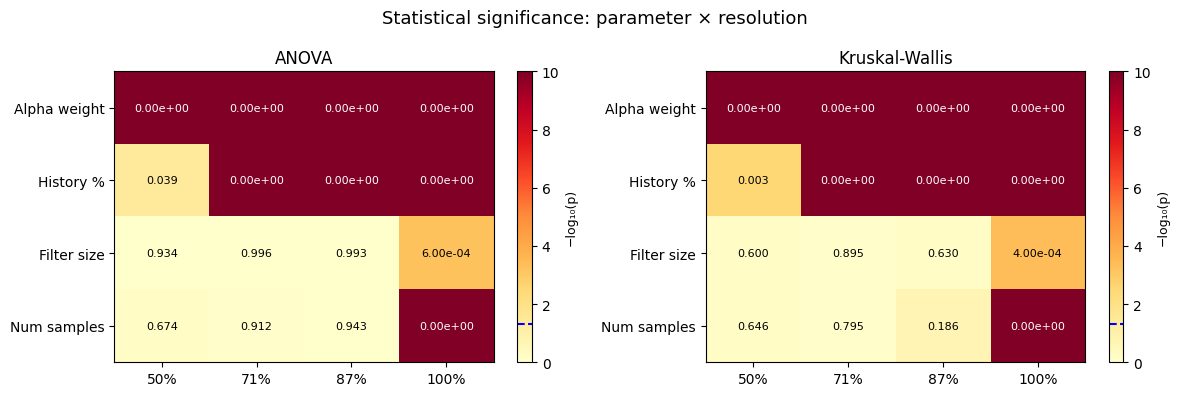

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

params = ['alpha_weight', 'hist_percent', 'filter_size', 'num_samples']
resolutions = [50, 71, 87, 100]
param_labels = {'alpha_weight': 'Alpha weight', 'filter_size': 'Filter size',
                'hist_percent': 'History %',    'num_samples': 'Num samples'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, test, label in zip(axes, ['anova_p', 'kw_p'], ['ANOVA', 'Kruskal-Wallis']):
    # Build matrix: rows = params, cols = resolutions
    matrix = np.zeros((len(params), len(resolutions)))
    for i, param in enumerate(params):
        for j, res in enumerate(resolutions):
            row = results_df[(results_df['parameter'] == param) & 
                             (results_df['resolution'] == res)]
            matrix[i, j] = row[test].values[0]

    # Plot -log10(p) so higher = more significant
    log_matrix = -np.log10(np.clip(matrix, 1e-300, 1))
    im = ax.imshow(log_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=10)   
    # Annotate each cell with the actual p-value
    for i in range(len(params)):
        for j in range(len(resolutions)):
            p = matrix[i, j]
            text = f"{p:.2e}" if p < 0.001 else f"{p:.3f}"
            ax.text(j, i, text, ha='center', va='center', fontsize=8,
                    color='black' if log_matrix[i,j] < 4 else 'white')

    ax.set_xticks(range(len(resolutions)))
    ax.set_xticklabels([f"{r}%" for r in resolutions])
    ax.set_yticks(range(len(params)))
    ax.set_yticklabels([param_labels[p] for p in params])
    ax.set_title(label, fontsize=12)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("−log₁₀(p)", fontsize=9)
    cbar.ax.axhline(-np.log10(0.05), color='blue', linewidth=1.5, linestyle='--')

plt.suptitle("Statistical significance: parameter × resolution", fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
from scipy.stats import levene

for (param, res), group in df.groupby(['parameter', 'resolution']):
    groups_by_value = [g['score_demeaned'].values 
                       for _, g in group.groupby('value')]
    stat, p = levene(*groups_by_value)
    print(f"{param:15} res={res}  levene_p={p:.4f}  equal_var={p >= 0.05}")

alpha_weight    res=50  levene_p=0.0881  equal_var=True
alpha_weight    res=71  levene_p=0.2065  equal_var=True
alpha_weight    res=87  levene_p=0.1129  equal_var=True
alpha_weight    res=100  levene_p=0.1422  equal_var=True
filter_size     res=50  levene_p=0.9652  equal_var=True
filter_size     res=71  levene_p=0.9762  equal_var=True
filter_size     res=87  levene_p=0.9997  equal_var=True
filter_size     res=100  levene_p=0.9916  equal_var=True
hist_percent    res=50  levene_p=0.0054  equal_var=False
hist_percent    res=71  levene_p=0.0328  equal_var=False
hist_percent    res=87  levene_p=0.0130  equal_var=False
hist_percent    res=100  levene_p=0.1058  equal_var=True
num_samples     res=50  levene_p=0.9402  equal_var=True
num_samples     res=71  levene_p=0.9374  equal_var=True
num_samples     res=87  levene_p=0.8727  equal_var=True
num_samples     res=100  levene_p=0.8907  equal_var=True


In [23]:
import altair as alt
import pandas as pd
import numpy as np

# Build long-form dataframe from results_df
plot_data = []
for _, row in results_df.iterrows():
    plot_data.append({
        'parameter':  row['parameter'],
        'resolution': f"{row['resolution']}%",
        'log_p_kw':   -np.log10(max(row['kw_p'], 1e-300)),
        'log_p_anova':-np.log10(max(row['anova_p'], 1e-300)),
        'kw_p':       row['kw_p'],
        'anova_p':    row['anova_p'],
        'kw_p_str':   f"{row['kw_p']:.2e}" if row['kw_p'] < 0.001 else f"{row['kw_p']:.3f}",
        'anova_p_str':f"{row['anova_p']:.2e}" if row['anova_p'] < 0.001 else f"{row['anova_p']:.3f}",
    })

df_plot = pd.DataFrame(plot_data)

param_order = ['alpha_weight', 'filter_size', 'hist_percent', 'num_samples']
param_labels = {'alpha_weight': 'Alpha weight', 'filter_size': 'Filter size',
                'hist_percent': 'History %',    'num_samples': 'Num samples'}
df_plot['parameter_label'] = df_plot['parameter'].map(param_labels)
param_label_order = [param_labels[p] for p in param_order]
res_order = ['50%', '71%', '87%', '100%']

def make_heatmap(df, color_col, text_col, title):
    heatmap = alt.Chart(df).mark_rect().encode(
        x=alt.X('resolution:O', sort=res_order, title='Resolution'),
        y=alt.Y('parameter_label:O', sort=param_label_order, title=None),
        color=alt.Color(f'{color_col}:Q',
               scale=alt.Scale(scheme='yelloworangered', domain=[0, 10], clamp=True),
               legend=alt.Legend(title='−log₁₀(p)')),
    )

    text = alt.Chart(df).mark_text(fontSize=11).encode(
        x=alt.X('resolution:O', sort=res_order),
        y=alt.Y('parameter_label:O', sort=param_label_order),
        text=alt.Text(f'{text_col}:N'),
        color=alt.condition(
            alt.datum[color_col] > 5,
            alt.value('white'),
            alt.value('black')
        )
    )

    return (heatmap + text).properties(
        title=title, width=280, height=180
    )

kw_chart    = make_heatmap(df_plot, 'log_p_kw',    'kw_p_str',    'Kruskal-Wallis')
anova_chart = make_heatmap(df_plot, 'log_p_anova', 'anova_p_str', 'ANOVA')

chart = (kw_chart).properties(
    title=alt.TitleParams(
        'Statistical significance: parameter × resolution',
        anchor='middle'
    )
)

chart.show()

import vl_convert as vlc

vg_json = chart.to_dict()
png_data = vlc.vegalite_to_png(vg_json, scale=3)
with open('KW-test.png', 'wb') as f:
    f.write(png_data)


alt.LayerChart(...)